## Mapping Ocean Colour Data for the Northwestern Iberian Margine
### Subset Extent: 43.4°N, 40.6°N, 10.6°W, 8.4°W
#### Tatjana Noah Steixner

In [4]:
#import necessary modules
import xarray as xr #import netcdf datasets
import matplotlib.pyplot as plt #plotting
import numpy as np  #general transformations
import matplotlib.colors as mcolors #colourmaps for plotting
import matplotlib.dates as mdates #formatting axes as dates
import cmocean #specialised ocean colourmaps
import cartopy.crs as ccrs #plotting using cartopy
import cartopy.feature as cfeature #adding features

In [ ]:
#load ESA-CCI ocean colour climatology from current directory

oc_data = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")
oc_data #display

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

In [49]:

#data is not correctly sorted by time (1998-01-01 to 1997-12-01)
#sort by time and store only chlor_a data as new variable
oc_chla = oc_data.sortby("time")["chlor_a"]
oc_chla

<xarray.DataArray 'chlor_a' (time: 12, lat: 4320, lon: 8640)> Size: 2GB
[447897600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 96B 1997-09-04 1997-10-01 ... 1998-08-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

In [ ]:
#subset global dataset by coordinates used in case study
#define bounding box and use sel in combination with slicing to subset data

lat_min, lat_max = 40.59893, 43.40025
lon_min, lon_max = -10.60400, -8.39795

oc_chla_subset = oc_chla.sel(lat=slice(lat_max, lat_min),lon=slice(lon_min, lon_max))

#verify subsetting by selecting first and last value from coords 
print(f"lat:  {oc_chla_subset.lat.values[[0, -1]]}") 
print(f"lon:  {oc_chla_subset.lon.values[[0, -1]]}") 
#there is upscaling to lat_min and lon_max as values not exactly matched in intervals of coordinate grid
#verify subsetting has retained all time values by printing shape
print(f"shape: {oc_chla_subset.shape}") 

lat:  [43.39583333 40.60416667]
lon:  [-10.5625  -8.4375]
shape: (12, 68, 52)


<xarray.DataArray 'chlor_a' (time: 12, lat: 68, lon: 52)> Size: 170kB
[42432 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 96B 1997-09-04 1997-10-01 ... 1998-08-01
  * lat      (lat) float64 544B 43.4 43.35 43.31 43.27 ... 40.69 40.65 40.6
  * lon      (lon) float64 416B -10.56 -10.52 -10.48 ... -8.521 -8.479 -8.438
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

In [ ]:
#load bathymetry data
#is dowloaded DF compatible netCDF
#open as previously, but specify engine

bathy = xr.open_dataset("gmrt_bathy_grid.grd", engine="netcdf4")
bathy #display

<xarray.Dataset> Size: 55MB
Dimensions:   (lat: 3432, lon: 2004)
Coordinates:
  * lat       (lat) float64 27kB 40.6 40.6 40.6 40.6 ... 43.4 43.4 43.4 43.4
  * lon       (lon) float64 16kB -10.6 -10.6 -10.6 -10.6 ... -8.401 -8.4 -8.399
Data variables:
    altitude  (lat, lon) float64 55MB ...
Attributes:
    title:        GMRT Grid
    history:      Projection: Cylindrical Equidistant\nExtracted from the Glo...
    Conventions:  COARDS,CF-1.6
    GMT_version:  4.5.7

In [22]:
bathy["altitude"] #check attributes of data 

<xarray.DataArray 'altitude' (lat: 3432, lon: 2004)> Size: 55MB
[6877728 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 27kB 40.6 40.6 40.6 40.6 40.6 ... 43.4 43.4 43.4 43.4
  * lon      (lon) float64 16kB -10.6 -10.6 -10.6 -10.6 ... -8.401 -8.4 -8.399
Attributes:
    long_name:      altitude
    standard_name:  altitude
    units:          m
    actual_range:   [-4516.71715588  1046.78582192]

In [ ]:
#understand dataset:
#it appears that import of .grd data does not restructure grid as intended
#x_range, y_range and z_range are arrays of length 2 defining extent of longitude, latitude and elevation, respectively
print(bathy["x_range"].data)
print(bathy["y_range"].data)
print(bathy["z_range"].data)

#spacing refers to spacing along x and y axis (?) and dim defines dimension of coordinate grid
print(bathy["spacing"].data)
print(bathy["dimension"].data)

#z variable appears to contain data as single array and needs to be reconstructed as a grid
print(bathy["z"].data)
#check for number of missing values, corresponds to land mass within grid
print(np.sum(np.isnan(bathy["z"].values)))

[-10.40185547  -8.19580078]
[40.59727063 43.40025826]
[-4369.5859375   1391.35461426]
[0.00219946 0.00163344]
[1004 1717]
[-3432.75 -3428.25 -3409.   ...      nan      nan      nan]
2008


In [4]:
#reconstruct grid
#extract dimension metadata, saved as data variables with 2 points each
x_min, x_max = bathy['x_range'].values
y_min, y_max = bathy['y_range'].values
z_min, z_max = bathy['z_range'].values
nx, ny       = bathy['dimension'].values #dimension of coordinate grid

#reconstruct coordinate grid
#use linspace for equal spacing
long = np.linspace(x_min, x_max, nx)
lat = np.linspace(y_min, y_max, ny)
lat = lat[::-1] #reverse, as values run S-N [40.59°, 43.40°] and will result in flipped map 

#check reconstructed grid matches intended spacing 
print(long[1]-long[0])
print(bathy["spacing"].data[0])
print(lat[1]-lat[0])
print(bathy["spacing"].data[1])

#reshape bathymetry data into dimensions of coordinate grid
bathymetry_data = bathy['z'].values.reshape(ny, nx)

#build a clean xarray dataset
bathy_reconst = xr.Dataset(
    {'bathymetry_data': (['y', 'x'], bathymetry_data)},
    coords={
        'x': (['x'], long, {'units': 'degrees_east',  'long_name': 'Longitude'}),
        'y': (['y'], lat, {'units': 'degrees_north', 'long_name': 'Latitude'}),
    },
    attrs={
        'title':      'Reconstructed GMRT Bathymetry',
        'x_range':    [x_min, x_max],
        'y_range':    [y_min, y_max],
        'z_range':    [z_min, z_max],
        'dimensions': [nx, ny],
})

0.00219945631854479
0.002199456318544367
-0.0016334426751285491
0.001633442675127779


In [5]:
#check if xarray Dataset was reconstructed as intended
print(bathy_reconst)

<xarray.Dataset> Size: 14MB
Dimensions:          (y: 1717, x: 1004)
Coordinates:
  * y                (y) float64 14kB 43.4 43.4 43.4 43.4 ... 40.6 40.6 40.6
  * x                (x) float64 8kB -10.4 -10.4 -10.4 ... -8.2 -8.198 -8.196
Data variables:
    bathymetry_data  (y, x) float64 14MB -3.433e+03 -3.428e+03 ... nan nan
Attributes:
    title:       Reconstructed GMRT Bathymetry
    x_range:     [np.float64(-10.40185546875), np.float64(-8.19580078125)]
    y_range:     [np.float64(40.59727063442025), np.float64(43.40025826493952)]
    z_range:     [np.float64(-4369.5859375), np.float64(1391.3546142578125)]
    dimensions:  [np.int32(1004), np.int32(1717)]


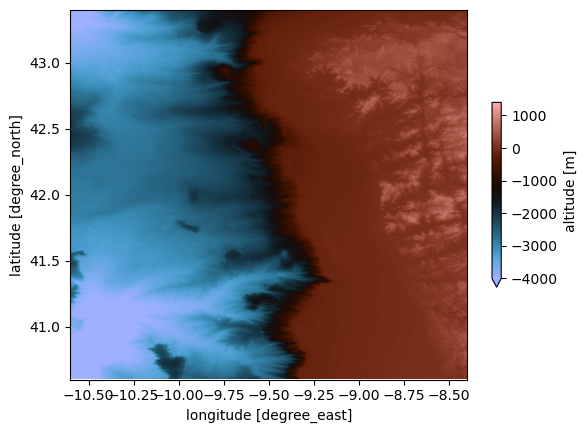

In [ ]:
#plot bathymetry using xarray matplotlib integration
bathy.altitude.plot(cmap="berlin", vmin=-4000, vmax=1400,
                     cbar_kwargs={'orientation': 'vertical', 'shrink': 0.5})

/tmp/ipykernel_13848/3310193986.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


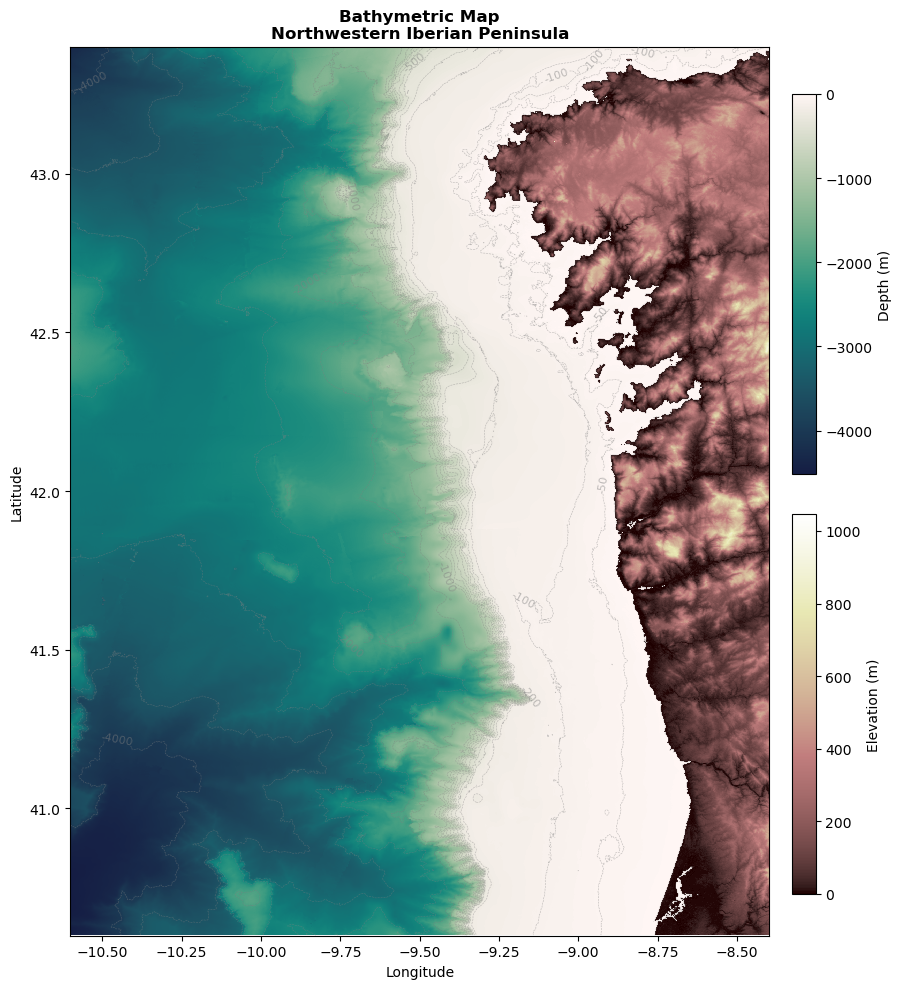

In [24]:


#split reconstructed bathymetric data into ocean and land data
#this allows for separation of colourmaps, better definition of land-sea transition 
#plot using pcolourmesh (can plot n-D arrays)
bathymetry_data = bathy["altitude"] #extract only altitude
long = bathymetry_data.lon.values #long and lat values as array
lat = bathymetry_data.lat.values

vals_ocean = np.where(bathymetry_data <= 0, bathymetry_data, np.nan) #ocean values = negative and 0 values
vals_land  = np.where(bathymetry_data >  0, bathymetry_data, np.nan) #land values = positive values

#create subplot
fig, ax = plt.subplots(figsize=(12, 10))

#plot ocean values, define colourmap extent
im_ocean = ax.pcolormesh(long, lat, vals_ocean,
    cmap=cmocean.cm.tempo_r, #ocean-specific colourmap
    vmin=vals_ocean[~np.isnan(vals_ocean)].min(),
    vmax=0)

#plot land values, separate colourmap
im_land = ax.pcolormesh(long, lat, vals_land,
    cmap="pink",
    vmin=0,
    vmax=vals_land[~np.isnan(vals_land)].max())

#adjust spacing for colourbars, stack vertically
fig.subplots_adjust(right=0.78) 

#ocean colourbar
cax_ocean = fig.add_axes([0.81, 0.52, 0.02, 0.38])  
cbar_ocean = plt.colorbar(im_ocean, cax=cax_ocean)
cbar_ocean.set_label("Depth (m)", fontsize=10)

#land colourbar
cax_land = fig.add_axes([0.81, 0.10, 0.02, 0.38])
cbar_land = plt.colorbar(im_land, cax=cax_land)
cbar_land.set_label("Elevation (m)", fontsize=10)

#add contour lines at relevant depths
contour_levels = [-4000, -3500, -3000, -2500, -2000, -1500, -1000, -900, -800, -700, -600, -500, -400, -300, -200, -100, -50, 0]
cont = ax.contour(long, lat, bathymetry_data, levels=contour_levels,
           colors="gray", linewidths=0.4, alpha=0.5)
#label selected levels
label_levels = [-50, -100, -200, -500, -1000, -2000, -4000]
ax.clabel(cont, levels=label_levels, fontsize=8, fmt="%d", inline=True, inline_spacing=3)

#set labels and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Bathymetric Map\nNorthwestern Iberian Peninsula", fontweight="bold")
ax.set_aspect("equal")

#display and save figure
plt.tight_layout()
plt.savefig("bathy_plot_nw_iberia.png", dpi=300)
plt.show()


Chl-a range: 0.3043 – 8.88 mg m⁻³
Median Chl-a: 0.4530


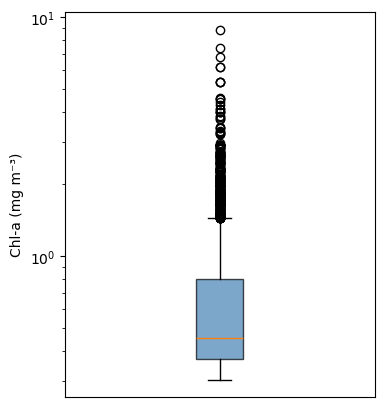

In [ ]:
#calculate annual mean 
yearly_mean = oc_chla_subset.mean(dim="time")
#check for range in chl-a data for scale bar
print(f"Chl-a range: {np.nanmin(yearly_mean):.4f} – {np.nanmax(yearly_mean):.2f} mg m⁻³") #range of chl-a values
print(f"Median Chl-a: {np.nanmedian(yearly_mean):.4f}") #median
#check if high values are outliers, as outliers will skew colourmap
ym_diagnostic = yearly_mean.values.flatten() #flatten n-D array into 1-D array
ym_diagnostic = ym_diagnostic[~np.isnan(ym_diagnostic)] #drop NaNs

#simple boxplot
fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(ym_diagnostic, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_ylabel("Chl-a (mg m⁻³)")
ax.set_yscale('log')
ax.set_xticks([])
plt.show()

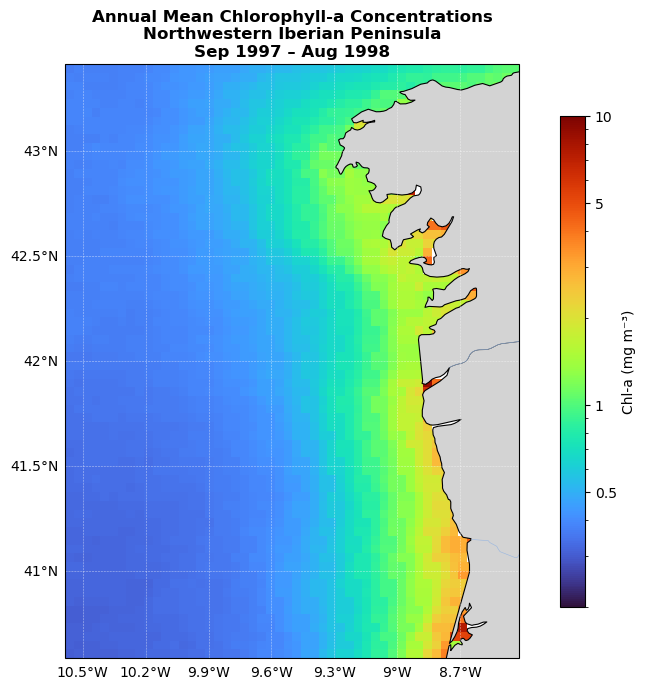

In [34]:
#mapping annual mean chl-a concentrations using appropriate log scale
lats = yearly_mean.lat.values #extract long and lat as array
lons = yearly_mean.lon.values

#initialise plot, Plate Carree ccrs to correctly represent coordinates
fig, ax = plt.subplots(figsize=(9,7),subplot_kw={"projection": ccrs.PlateCarree()})

#colormesh can plot n-D array data, specify coordinates (else global plot)
im = ax.pcolormesh(lons, lats, yearly_mean,cmap='turbo',   
    norm=mcolors.LogNorm(vmin=0.2, vmax=10), 
    transform=ccrs.PlateCarree())

#add cartopy features: land polygon, coastline, borders, major rivers
#specify zorder to correctly stack features
ax.add_feature(cfeature.LAND,facecolor="lightgray", zorder=1)
ax.add_feature(cfeature.COASTLINE,linewidth=0.8,zorder=2)
ax.add_feature(cfeature.BORDERS,linewidth=0.4,zorder=2)
ax.add_feature(cfeature.RIVERS,linewidth=0.4, zorder=2)

#add gridlines, remove top and right labels
gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                  color="white", alpha=0.6, linestyle="--")
gl.top_labels   = False
gl.right_labels = False

#plot colourbar, add custom labels
cbar = plt.colorbar(im, fraction=0.03, pad=0.05, ticks=[0.15, 0.5, 1, 5, 10, 20])
cbar.ax.set_yticklabels(["0.1", "0.5", "1", "5", "10", "20"])
cbar.set_label("Chl-a (mg m⁻³)", fontsize=10)

#set title
ax.set_title("Annual Mean Chlorophyll-a Concentrations\nNorthwestern Iberian Peninsula\nSep 1997 – Aug 1998",
             fontweight="bold", fontsize=12)
plt.tight_layout()

plt.savefig("annual_ chla_nw_iberia.png", dpi=300)
plt.show()

Chl-a range: 0.1717 – 22.18 mg m⁻³
Median Chl-a: 0.4921


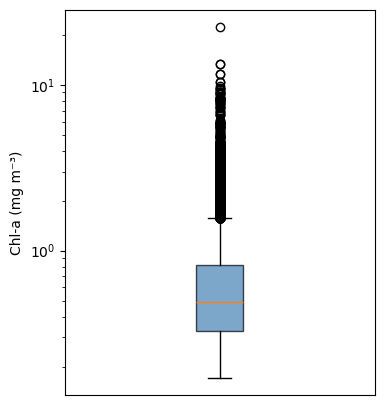

In [38]:
#plot monthly mean chorophyll concentrations in faceted plot
#requires original data
#check data range
print(f"Chl-a range: {np.nanmin(oc_chla_subset):.4f} – {np.nanmax(oc_chla_subset):.2f} mg m⁻³") #range of chl-a values
print(f"Median Chl-a: {np.nanmedian(oc_chla_subset):.4f}") #median

#as previously, diagnostic boxplot to identify outliers
oc_all_diagnostic = oc_chla_subset.values.flatten() #flatten n-D array
oc_all_diagnostic = oc_all_diagnostic[~np.isnan(oc_all_diagnostic)] #drop NaNs

#simple boxplot
fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(oc_all_diagnostic, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_ylabel("Chl-a (mg m⁻³)")
ax.set_yscale('log')
ax.set_xticks([])

plt.show()
#max value appears to be outlier, set scale to max of 15

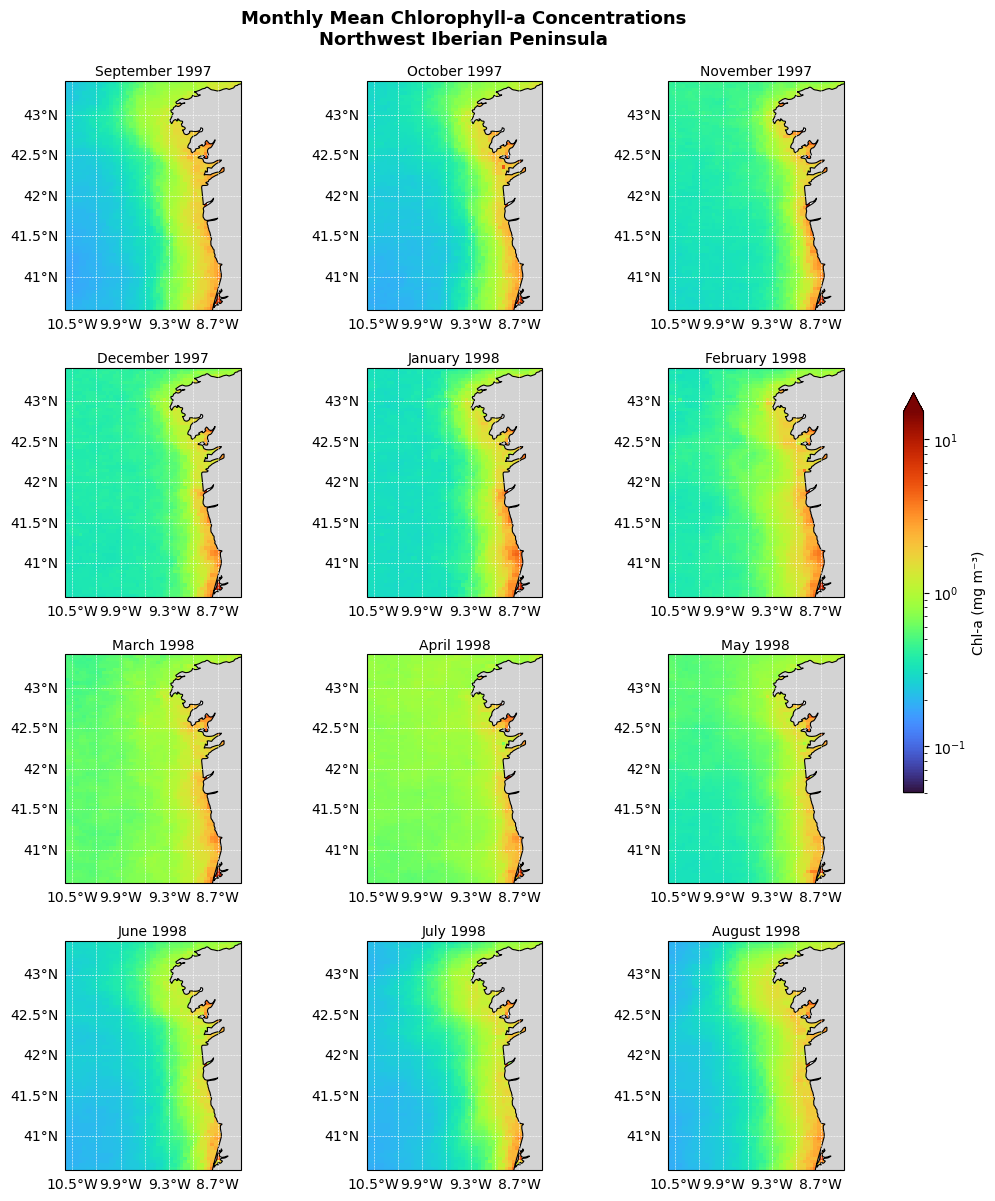

In [57]:
#create facetted plot using xarray/matplotlib integration
#plot titles
titles = ["September 1997", "October 1997", "November 1997", "December 1997", "January 1998", 
          "February 1998", "March 1998", "April 1998", "May 1998", "June 1998", "July 1998", "August 1998"]


fg = oc_chla_subset.plot(col='time',col_wrap=3,cmap='turbo',
    norm=mcolors.LogNorm(vmin=0.05, vmax=15.), #log scale
    transform=ccrs.PlateCarree(), #specify ccrs
    subplot_kws={'projection': ccrs.PlateCarree()},
    cbar_kwargs={'orientation': 'vertical', 'shrink': 0.3, "label":"Chl-a (mg m⁻³)"})

#loop over flattened axes to add cartopy features to each subplot
#trick using enumerate allows for list access
for i, ax in enumerate(fg.axs.flat):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', color='white')
    gl.right_labels = False
    gl.top_labels = False
    
    ax.set_title(titles[i], fontsize=10, pad=4)
    

#customise layout, creating space for subplot labels, colourbar and title
fg.fig.subplots_adjust(top=0.92, right=0.88, hspace=0.25, wspace=0.15)

#position free colourbar
fg.cbar.ax.set_position([0.94, 0.2, 0.02, 0.6])  # [left, bottom, width, height]

#set title
fg.fig.suptitle("Monthly Mean Chlorophyll-a Concentrations\nNorthwest Iberian Peninsula", 
                fontsize=13, fontweight='bold')

plt.savefig("monthly_ chla_nw_iberia.png", dpi=300)
plt.show()

In [54]:
oc_chla_subset.coords["time"]

<xarray.DataArray 'time' (time: 12)> Size: 96B
array(['1997-09-04T00:00:00.000000000', '1997-10-01T00:00:00.000000000',
       '1997-11-01T00:00:00.000000000', '1997-12-01T00:00:00.000000000',
       '1998-01-01T00:00:00.000000000', '1998-02-01T00:00:00.000000000',
       '1998-03-01T00:00:00.000000000', '1998-04-01T00:00:00.000000000',
       '1998-05-01T00:00:00.000000000', '1998-06-01T00:00:00.000000000',
       '1998-07-01T00:00:00.000000000', '1998-08-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 96B 1997-09-04 1997-10-01 ... 1998-08-01
Attributes:
    standard_name:  time
    axis:           T

In [ ]:
#plot seasonal cycle

mean_sc = mean_sc = (oc_chla_subset.mean(dim=['lat', 'lon'], skipna=True)).values #mean by month over entire grid - specify dimension as lon and lat
point_sc = oc_chla_subset.sel(lat=41.5, lon=-9, method="nearest").values #select single coordinate 
time_index = oc_chla.coords["time"].values #transform all to 1-D array for plotting

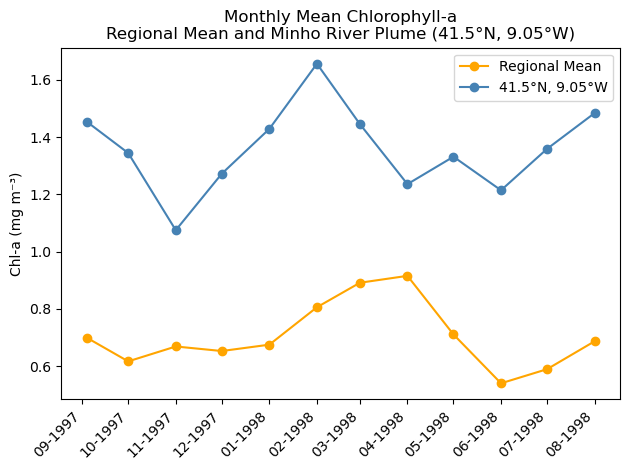

In [48]:
#initiate subplote
fig, ax = plt.subplots()

#plot mean and point seasonal cycle with label for reference
ax.plot(time_index, mean_sc,  color='orange', marker='o', label='Regional Mean')
ax.plot(time_index, point_sc, color='steelblue', marker='o', label='41.5°N, 9.05°W')

#format dates as MM-YYYY and adjust ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right')

#set label, title, legend
ax.set_ylabel('Chl-a (mg m⁻³)')
ax.set_title('Monthly Mean Chlorophyll-a\nRegional Mean and Minho River Plume (41.5°N, 9.05°W)')
ax.legend()

plt.tight_layout()

plt.savefig("region_minho_mean_graph.png", dpi=300)
plt.show()